# ANA540 Final project 

## Abstract

## Introduction

The number of international tourists visiting Japan has dramatically increased thus making the country a worldwide destination for travelers. The substantial economic expansion has created a serious deficit of available lodging particularly in locations with high tourist interests and urban centers. Airbnb and similar platforms have provided essential substitute accommodations by enabling users to book rooms in various sized facilities spread throughout Japan.

The increasing demand promotes new investment possibilities and innovative solutions in the short-term rental business. The proposed analysis focuses on Airbnb booking trends within Japan's specific area to identify marketplace requirements for customer demand and generate mission-critical business intelligence. The research aims to support strategic choices through data analytics and machine learning methods for shortened rental market investors and owners alongside hospitality entrepreneurs looking to excel in this business environment.

As part of my CPT, I’m exploring new business opportunities in the hospitality and property management space. This project aims to analyze Airbnb booking occupancy in a specific area in Japan, providing actionable insights that could support investment or operational decisions.

## Methodology

### EDA
This is the dataset for AirBnB occupancy rate prediction we got from Airbnb on April 2025.

The target variable, Occupancy rate has right skewness, but it is not severe. also we can say it's lightly uniform distribution. 
Also rating system creates some unique distribution.Because of the rating system expects user to put 5 star as a baseline, a lot of rating related features are skewed toward 5. Given many different features, we may need to normalize a lot of features to run models. 
Regarding correlation, we observe that highly correlated each other in Rating and Price group features. It indicates the potential of multicollinearity, we may need to consider PCA later.

Also we see some quick insights and potential preprocessing for occupancy rate prediction from initial simple linear regression model. Higher contribution features are mostly missing value, so we may need to cleaning up those features. 


In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
import os 
from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

os.chdir('/Users/nkohei/Workspace/plaize/airbnb/ocp_analysis')
df = pd.read_csv('df_final.csv')

print("Dataset dimensions:")
print(df.shape)

print("Dataset samples")
print(df.head())

print("Dataset description")
print(df.describe())


print("Dataset info")
print(df.info())

print("Dataset missing values")
print(df.isnull().sum())   

Dataset dimensions:
(1287, 41)
Dataset samples
               room_id  occupancy_rate  propertyType_major_Entire home  \
0  1288180664022835353        0.433333                            True   
1  1342381500367926145        0.900000                           False   
2  1302716270088739688        0.500000                            True   
3             33020852        0.466667                           False   
4   917140594942569847        0.700000                            True   

   propertyType_major_Entire rental unit  propertyType_major_Entire villa  \
0                                  False                            False   
1                                  False                            False   
2                                  False                            False   
3                                  False                            False   
4                                  False                            False   

   propertyType_major_Other  propertyType_maj

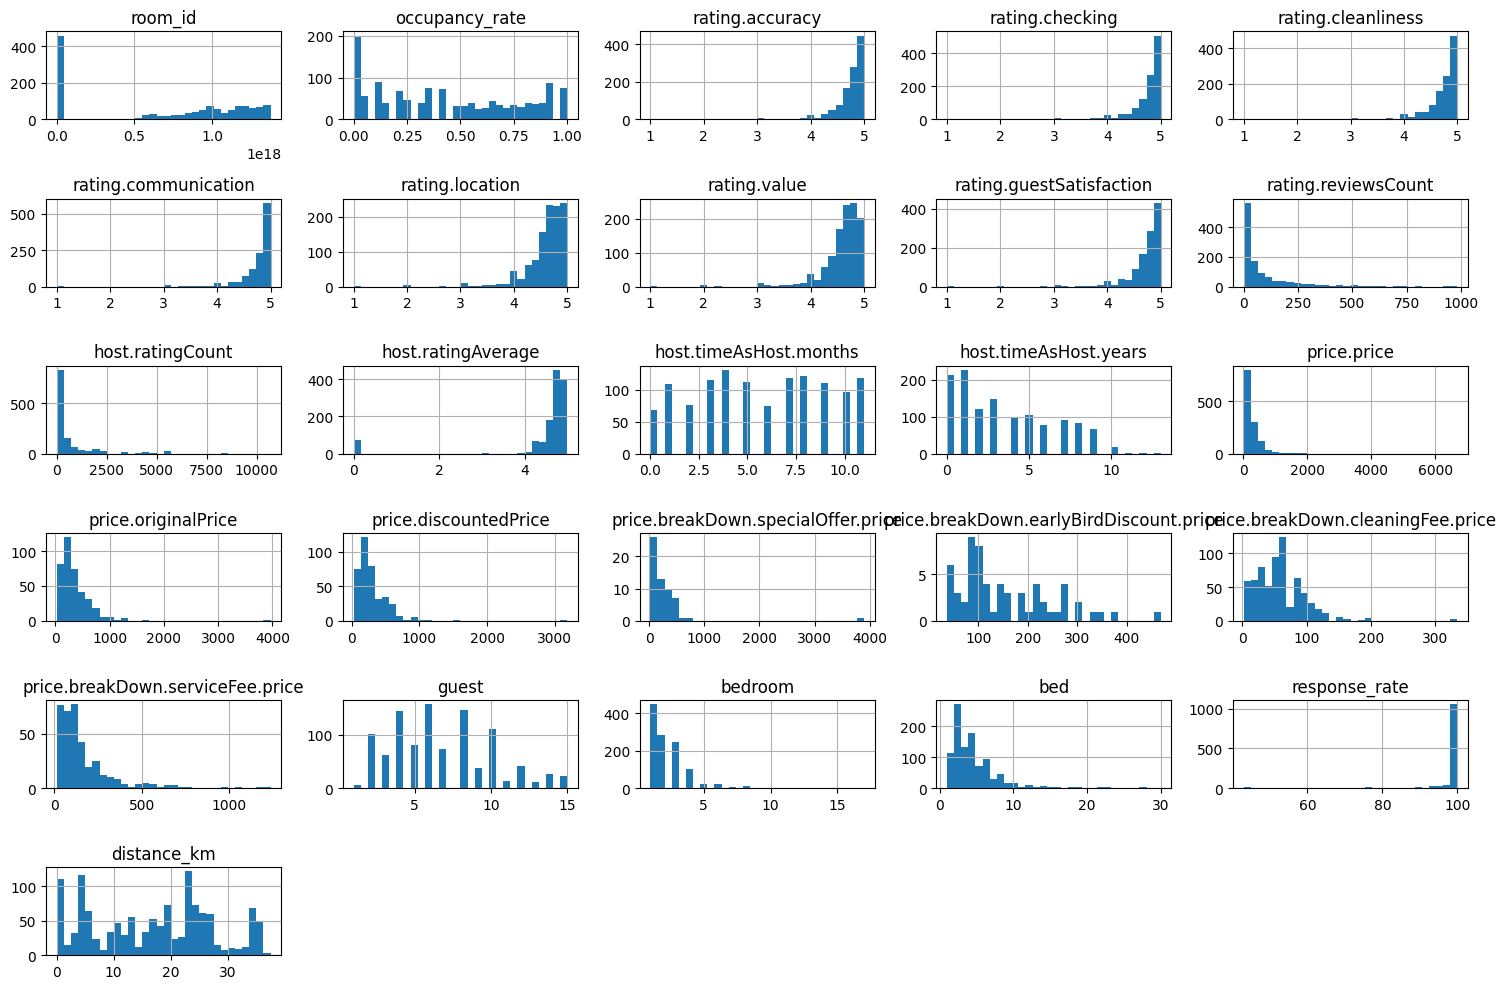

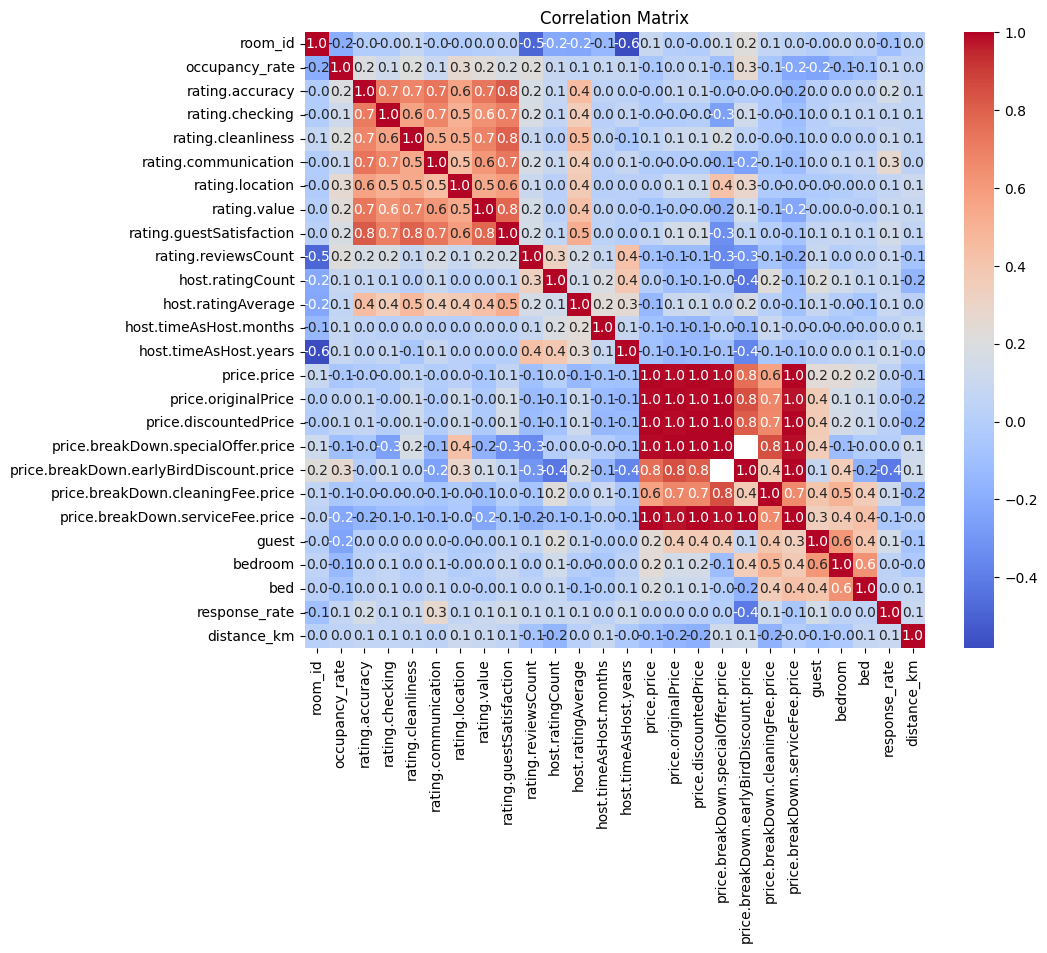

In [2]:
num_cols = df.select_dtypes(include=['number']).columns

df[num_cols].hist(bins=30, figsize=(15, 10))
plt.tight_layout()
plt.show()


corr_matrix = df[num_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".1f")
plt.title("Correlation Matrix")
plt.show()

Mean Squared Error: 0.094
R^2 Score: 0.083


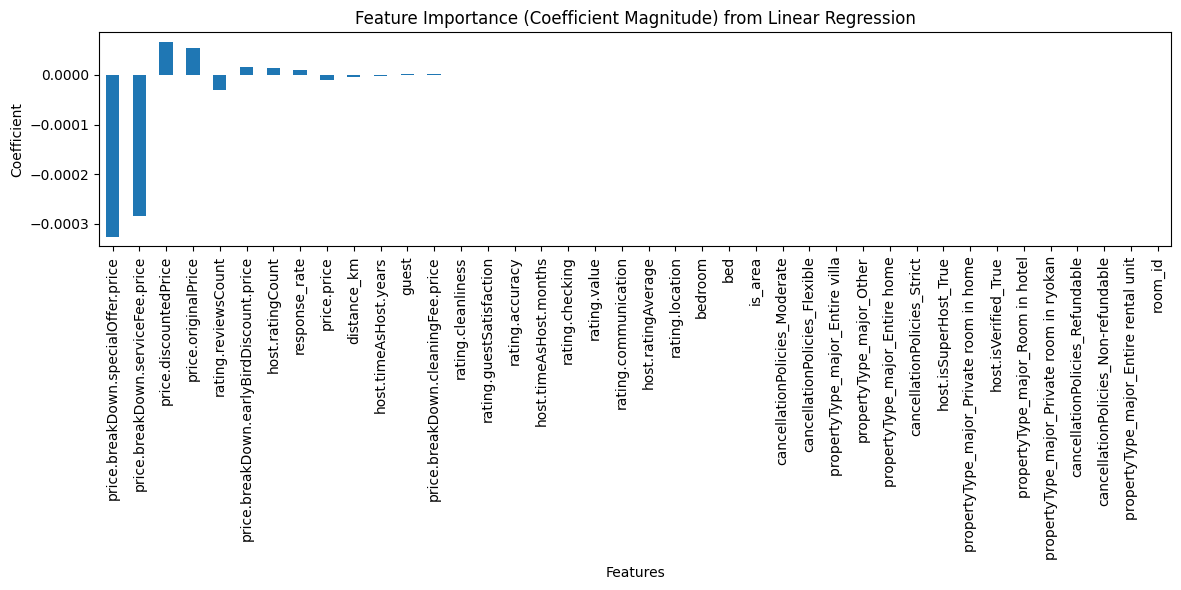

In [3]:
df_filled = df.fillna(0)
df_numeric = pd.get_dummies(df_filled, drop_first=True)


X = df_numeric.drop(columns=['occupancy_rate'])
y = df_numeric['occupancy_rate']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)


lr_model = LinearRegression()
lr_model.fit(X_train, y_train)


y_pred = lr_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("Mean Squared Error: {:.3f}".format(mse))
print("R^2 Score: {:.3f}".format(r2))


coefficients = lr_model.coef_
feature_importance = pd.Series(coefficients, index=X_train.columns)

# Sort the feature importance by absolute value
feature_importance = feature_importance.reindex(feature_importance.abs().sort_values(ascending=False).index)

plt.figure(figsize=(12, 6))
feature_importance.plot(kind='bar')
plt.xlabel("Features")
plt.ylabel("Coefficient")
plt.title("Feature Importance (Coefficient Magnitude) from Linear Regression")
plt.tight_layout()
plt.show()

### Data Preprocessing

Data pre-processing is an important process to train the adequate model without any unexpected influence from data itself. 
 
In order to train the model without data leaking, I split dataset into train and test by using train_test_split method. After that we removed NULL included rows due to model training constrains. Some model won't be executed with Null values as features.  
Also some columns contain True and False as string data, so I converted that into Boolean to treat data properly.  Finally, I also applied standardization to dataset and prepared standardized dataset separately. Even though I planed to use RandomForest as primary model, I prepared separated dataset because we may switch to logistic regression or other type of model which may be influenced by huge gap of feature units. 

In [4]:
## Select only meaningful columns

li_columns = ['room_id', 'occupancy_rate', 'propertyType_major_Entire home',
'propertyType_major_Entire rental unit',
'propertyType_major_Entire villa', 'propertyType_major_Other',
'propertyType_major_Private room in home',
'propertyType_major_Private room in ryokan',
'propertyType_major_Room in hotel', 'cancellationPolicies_Flexible',
'cancellationPolicies_Moderate', 'cancellationPolicies_Non-refundable',
'cancellationPolicies_Refundable', 'cancellationPolicies_Strict',
'rating.accuracy', 'rating.checking', 'rating.cleanliness',
'rating.communication', 'rating.location', 'rating.value',
'rating.guestSatisfaction', 'rating.reviewsCount', 'host.isSuperHost',
'host.isVerified', 'host.ratingCount', 'host.ratingAverage',
'host.timeAsHost.months', 'host.timeAsHost.years', 'price.price',
'guest', 'bedroom', 'bed', 'response_rate', 'distance_km', 'is_area']
df = df[li_columns]

## Train test split

print('before split: ', df.shape)
y = df['occupancy_rate']
X = df.drop(['occupancy_rate','room_id'], axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

print('after split: ', X_train.shape, X_test.shape, y_train.shape, y_test.shape)



## Missing Value
X_train.isnull().sum()
X_tr_drop_idx = ~X_train.isnull().any(axis=1)
X_train = X_train[X_tr_drop_idx]
y_train = y_train[X_tr_drop_idx]

X_te_drop_idx = ~X_test.isnull().any(axis=1)
X_test = X_test[X_te_drop_idx]
y_test = y_test[X_te_drop_idx]

print("after NA drop:", X_train.shape, y_train.shape)

## Transform
X_train['host.isVerified'] = X_train['host.isVerified'].astype(bool)
X_train['host.isSuperHost'] = X_train['host.isSuperHost'].astype(bool)

## Scaling

print("\nScaled dataset size")
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(X_train_scaled.shape, X_test_scaled.shape)
print(y_train.shape, y_test.shape)

print("\nMissing values in scaled dataset")
print(np.isnan(X_train_scaled).sum())


before split:  (1287, 35)
after split:  (1029, 33) (258, 33) (1029,) (258,)
after NA drop: (552, 33) (552,)

Scaled dataset size
(552, 33) (138, 33)
(552,) (138,)

Missing values in scaled dataset
0


### Model experiment

Given outputs from each model with default parameter, the range of MSE is 0.09 to 0.1 across Linear models and Tree models. However R2 in Tree model is higher than linear in general except for Decesion tree.
Based on these findings, I guess this data does not meet Linear regression assumption. Later this Model experiment, I conducted EDA for linearity assumption and PCA. However performance didn't improve as we expected.
Hence Tree model like RondomForest and GBRT may have outperforme among these models.

In [5]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

def evaluate_regression(model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    print(f"\n {model.__class__.__name__}:")
    print(f"  MSE:  {mse:.4f}")
    print(f"  RMSE: {rmse:.4f}")
    print(f"  R2:   {r2:.4f}\n")
    return y_pred

print("Dataset quality check")
print("NaNs in X_train_scaled:", np.isnan(X_train_scaled).sum())
print("NaNs in X_test_scaled:", np.isnan(X_test_scaled).sum())
print("NaNs in y_train:", np.isnan(y_train).sum())
print("NaNs in y_test:", np.isnan(y_test).sum())

linear_reg = LinearRegression()
ridge_reg = Ridge()
lasso_reg = Lasso()
elastic_net = ElasticNet()
tree_reg = DecisionTreeRegressor()
rf_reg = RandomForestRegressor()
gb_reg = GradientBoostingRegressor()

models = [linear_reg, ridge_reg, lasso_reg, elastic_net]

print("\nRegression models default evaluation")

for model in models:
    # print("\n"+model.__class__.__name__)
    y_pred = evaluate_regression(model, X_train_scaled, y_train, X_test_scaled, y_test)

print("\nTree models default evaluation")

tree_models = [tree_reg, rf_reg, gb_reg]
for tree_model in tree_models:
    y_pred = evaluate_regression(tree_model, X_train, y_train, X_test, y_test)

Dataset quality check
NaNs in X_train_scaled: 0
NaNs in X_test_scaled: 0
NaNs in y_train: 0
NaNs in y_test: 0

Regression models default evaluation

 LinearRegression:
  MSE:  0.0924
  RMSE: 0.3039
  R2:   0.0499


 Ridge:
  MSE:  0.0924
  RMSE: 0.3039
  R2:   0.0498


 Lasso:
  MSE:  0.1007
  RMSE: 0.3173
  R2:   -0.0354


 ElasticNet:
  MSE:  0.1007
  RMSE: 0.3173
  R2:   -0.0354


Tree models default evaluation

 DecisionTreeRegressor:
  MSE:  0.1234
  RMSE: 0.3513
  R2:   -0.2694


 RandomForestRegressor:
  MSE:  0.0689
  RMSE: 0.2625
  R2:   0.2915


 GradientBoostingRegressor:
  MSE:  0.0705
  RMSE: 0.2656
  R2:   0.2747



### EDA for Linear Regression Assumptions

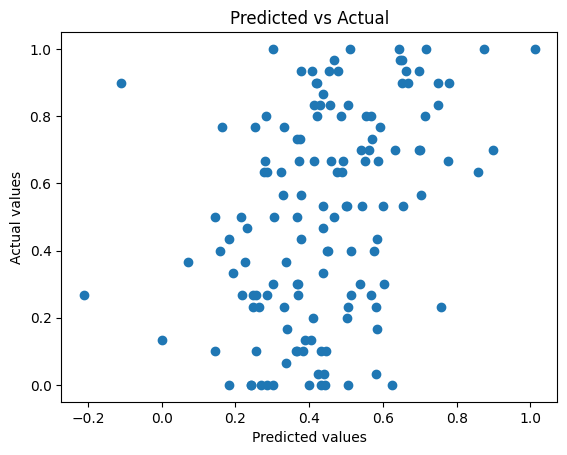

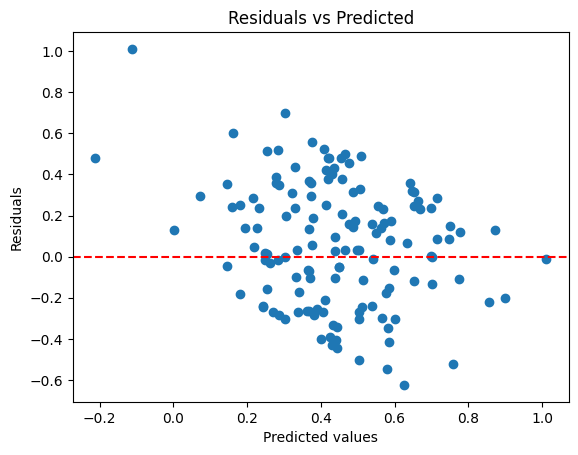

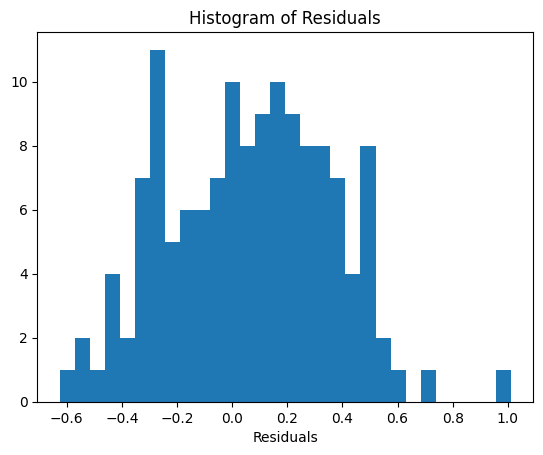

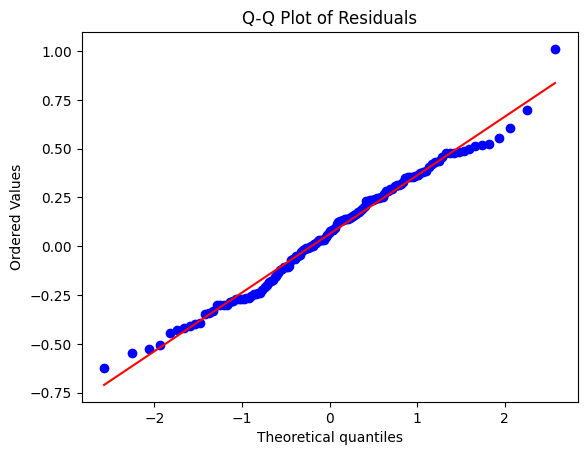

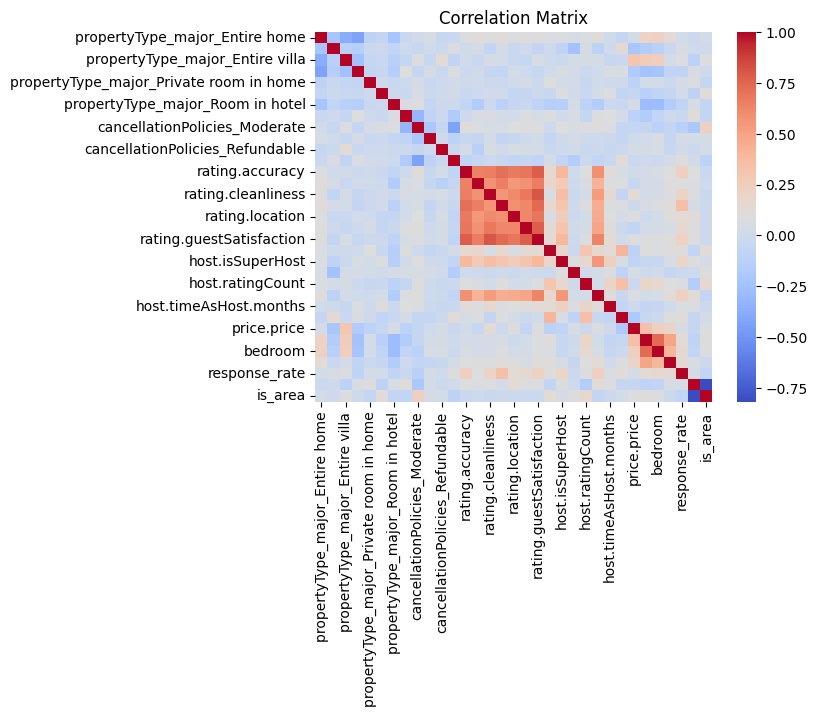

                                      feature       VIF
0              propertyType_major_Entire home  7.422822
1       propertyType_major_Entire rental unit  3.083941
2             propertyType_major_Entire villa  5.204998
3                    propertyType_major_Other  5.819359
4     propertyType_major_Private room in home  1.478306
5   propertyType_major_Private room in ryokan  1.302612
6            propertyType_major_Room in hotel  3.159145
7               cancellationPolicies_Flexible  1.647970
8               cancellationPolicies_Moderate  2.259684
9         cancellationPolicies_Non-refundable  1.284839
10            cancellationPolicies_Refundable  1.102420
11                cancellationPolicies_Strict  1.773938
12                            rating.accuracy  3.565421
13                            rating.checking  2.455072
14                         rating.cleanliness  3.375621
15                       rating.communication  3.200847
16                            rating.location  2

In [6]:
## Linear Regression Assumption 

### Linearity & Homoscedasticity 
y_pred = linear_reg.predict(X_test_scaled)
plt.scatter(y_pred, y_test)
plt.xlabel("Predicted values")
plt.ylabel("Actual values")
plt.title("Predicted vs Actual")
plt.show()

residuals = y_test - y_pred
plt.scatter(y_pred, residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted")
plt.show()

### Normality 
import scipy.stats as stats
plt.hist(residuals, bins=30)
plt.xlabel("Residuals")
plt.title("Histogram of Residuals")
plt.show()

stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q Plot of Residuals")
plt.show()


### Independence 
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor
import seaborn as sns
# If your features are in a DataFrame:
X_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)
corr_matrix = X_df.corr()

sns.heatmap(corr_matrix, annot=False, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

## VIF calculation
vif_data = pd.DataFrame()
vif_data["feature"] = X_df.columns
vif_data["VIF"] = [variance_inflation_factor(X_df.values, i) for i in range(X_df.shape[1])]
print(vif_data)

In [7]:
from sklearn.ensemble import IsolationForest
from sklearn.decomposition import PCA

def pca(x_train, x_test, n_components=1):
    pca = PCA(n_components=n_components)
    x_train = pca.fit_transform(x_train)
    x_test = pca.transform(x_test)

    return x_train, x_test

def isolation_forest(x_data, y_data=None):
    iforest = IsolationForest(contamination=0.1)
    iforest.fit(x_data)
    anomaly = iforest.predict(x_data)
    x_data = x_data[anomaly == 1]
    if y_data is not None:
        y_data = y_data[anomaly == 1]

    return x_data, y_data

X_train_pca, X_test_pca = pca(X_train,X_test, n_components=10)
X_train_scaled_pca, X_test_scaled_pca = pca(X_train_scaled,X_test_scaled, n_components=10)

X_train_cln, y_train_cln = isolation_forest(X_train_pca, y_train)
X_test_cln, y_test_cln = isolation_forest(X_test_pca, y_test)

X_train_scaled_cln= isolation_forest(X_train_scaled_pca)
X_test_scaled_cln = isolation_forest(X_test_scaled_pca)

print(X_train.shape)
print(X_train_pca.shape)
print(X_train_cln.shape)

linear_reg = LinearRegression()
ridge_reg = Ridge()
lasso_reg = Lasso()
elastic_net = ElasticNet()
tree_reg = DecisionTreeRegressor()
rf_reg = RandomForestRegressor()
gb_reg = GradientBoostingRegressor()

models = [linear_reg, ridge_reg, lasso_reg, elastic_net]
print("Regression with PCA and outliner removal")
for model in models:
    print(model.__class__.__name__)
    y_pred = evaluate_regression(model, X_train_cln, y_train_cln, X_test_cln, y_test_cln)



print("Regression without PCA and outliner removal")
for model in models:
    print(model.__class__.__name__)
    y_pred = evaluate_regression(model, X_train_scaled, y_train, X_test_scaled, y_test)


(552, 33)
(552, 10)
(496, 10)
Regression with PCA and outliner removal
LinearRegression

 LinearRegression:
  MSE:  0.1048
  RMSE: 0.3238
  R2:   -0.0659

Ridge

 Ridge:
  MSE:  0.1048
  RMSE: 0.3237
  R2:   -0.0654

Lasso

 Lasso:
  MSE:  0.1015
  RMSE: 0.3187
  R2:   -0.0324

ElasticNet

 ElasticNet:
  MSE:  0.1018
  RMSE: 0.3191
  R2:   -0.0352

Regression without PCA and outliner removal
LinearRegression

 LinearRegression:
  MSE:  0.0924
  RMSE: 0.3039
  R2:   0.0499

Ridge

 Ridge:
  MSE:  0.0924
  RMSE: 0.3039
  R2:   0.0498

Lasso

 Lasso:
  MSE:  0.1007
  RMSE: 0.3173
  R2:   -0.0354

ElasticNet

 ElasticNet:
  MSE:  0.1007
  RMSE: 0.3173
  R2:   -0.0354



### Hyperparameter Tuning

To save computational resource, I employed randomized Search CV for first hyperparameter tuning. Once I got the best model, I moved on to use GridSearchCV to fine tune the model. 
Given Randomized search CV parameters, I got the best model as follows. However the R2 gap between train and test, It obvious that the model is overfitting.


--- 
Random Forest Best Parameters: {'max_depth': 12, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 9, 'n_estimators': 262}

Gradient Boosting Best Parameters: {'learning_rate': np.float64(0.010515173225362662), 'max_depth': 14, 'max_features': 'sqrt', 'min_samples_leaf': 3, 'min_samples_split': 8, 'n_estimators': 247, 'subsample': np.float64(0.7553736512887829)}


| Model | Training Metrics | Test Metrics |
| --- | --- | --- |
| Random Forest |  |  |
| R² Score | 0.8196375624034089 | 0.2475105006442121 |
| MSE | 0.01810275276694341 | 0.07251118102345272 |
| RMSE | 0.1345464706595584 | 0.2692790021955903 |
| MAE | 0.10927513052952434 | 0.21543682138788572 |
| Gradient Boosting |  |  |
| R² Score | 0.9372422346083475 | 0.31290297909278575 |
| MSE | 0.006298918589867158 | 0.0662098494481734 |
| RMSE | 0.07936572679606203 | 0.25731274637719254 |
| MAE | 0.06449982791408394 | 0.20899431283346392 |

In [8]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

# For Random Forest
param_dist_rf = {
    'n_estimators': randint(100, 500),       
    'max_depth': [None] + list(range(3, 15)),
    'min_samples_split': randint(2, 15),     
    'min_samples_leaf': randint(1, 15),      
    'max_features': ['sqrt', 'log2', None]   
}

# For GBRT
param_dist_gbrt = {
    'learning_rate': uniform(0.01, 0.99),      
    'n_estimators': randint(50, 500),         
    'max_depth': [None] + list(range(3, 15)), 
    'min_samples_split': randint(2, 15),      
    'min_samples_leaf': randint(1, 15),       
    'max_features': ['sqrt', 'log2', None],   
    'subsample': uniform(0.5, 0.5)            
}

# Run Randomized Search
rf_random = RandomizedSearchCV(
    RandomForestRegressor(),
    param_distributions=param_dist_rf,
    n_iter=50,  # Number of random combinations to try
    cv=5,
    scoring='neg_mean_squared_error',
    random_state=42,
    verbose=1
)

gbrt_random = RandomizedSearchCV(
    GradientBoostingRegressor(),
    param_distributions=param_dist_gbrt,
    n_iter=50,  # Number of random combinations to try
    cv=5,
    scoring='neg_mean_squared_error',
    random_state=42,
    verbose=1
)

rf_random.fit(X_train_cln, y_train_cln)
gbrt_random.fit(X_train_cln, y_train_cln)

# Get the best parameters
print("Random Forest Best Parameters:", rf_random.best_params_)
print("Gradient Boosting Best Parameters:", gbrt_random.best_params_)

# Get the results and sort them
rf_results = pd.DataFrame(rf_random.cv_results_)
gbrt_results = pd.DataFrame(gbrt_random.cv_results_)

# Sort by mean test score to see the best combinations
rf_results = rf_results.sort_values('mean_test_score', ascending=False)
gbrt_results = gbrt_results.sort_values('mean_test_score', ascending=False)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Fitting 5 folds for each of 50 candidates, totalling 250 fits
Random Forest Best Parameters: {'max_depth': 7, 'max_features': None, 'min_samples_leaf': 3, 'min_samples_split': 2, 'n_estimators': 326}
Gradient Boosting Best Parameters: {'learning_rate': np.float64(0.010515173225362662), 'max_depth': 14, 'max_features': 'sqrt', 'min_samples_leaf': 3, 'min_samples_split': 8, 'n_estimators': 247, 'subsample': np.float64(0.7553736512887829)}


In [9]:
# Best score (neg_mean_squared_error)
print("Random Forest Best Score:", rf_random.best_score_)
print("Gradient Boosting Best Score:", gbrt_random.best_score_)

# Convert to MSE (since we used neg_mean_squared_error)
print("Random Forest MSE:", -rf_random.best_score_)
print("Gradient Boosting MSE:", -gbrt_random.best_score_)

Random Forest Best Score: -0.0667591776008175
Gradient Boosting Best Score: -0.06703584475979829
Random Forest MSE: 0.0667591776008175
Gradient Boosting MSE: 0.06703584475979829


In [18]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Create the model with best parameters
rf_final = RandomForestRegressor(
    n_estimators=rf_random.best_params_['n_estimators'],
    max_features=rf_random.best_params_['max_features'],
    max_depth=rf_random.best_params_['max_depth'],
    min_samples_split=rf_random.best_params_['min_samples_split'],
    min_samples_leaf=rf_random.best_params_['min_samples_leaf'],
    random_state=42
)

rf_final.fit(X_train_cln, y_train_cln)

y_pred_train = rf_final.predict(X_train_cln)
y_pred_test = rf_final.predict(X_test_cln)


print("RandomForestRegressor")
print("Best Parameters:", rf_random.best_params_)

print("\nTraining Metrics:")
print("R² Score:", r2_score(y_train_cln, y_pred_train))
print("MSE:", mean_squared_error(y_train_cln, y_pred_train))
print("RMSE:", np.sqrt(mean_squared_error(y_train_cln, y_pred_train)))
print("MAE:", mean_absolute_error(y_train_cln, y_pred_train))

print("\nTest Metrics:")
print("R² Score:", r2_score(y_test_cln, y_pred_test))
print("MSE:", mean_squared_error(y_test_cln, y_pred_test))
print("RMSE:", np.sqrt(mean_squared_error(y_test_cln, y_pred_test)))
print("MAE:", mean_absolute_error(y_test_cln, y_pred_test))

# Create the model with best parameters
gbrt_final = GradientBoostingRegressor(
    learning_rate=gbrt_random.best_params_['learning_rate'],
    n_estimators=gbrt_random.best_params_['n_estimators'],
    max_features=gbrt_random.best_params_['max_features'],
    max_depth=gbrt_random.best_params_['max_depth'],
    min_samples_split=gbrt_random.best_params_['min_samples_split'],
    min_samples_leaf=gbrt_random.best_params_['min_samples_leaf'],
    subsample=gbrt_random.best_params_['subsample'],
    random_state=42
)

gbrt_final.fit(X_train_cln, y_train_cln)

y_pred_train = gbrt_final.predict(X_train_cln)
y_pred_test = gbrt_final.predict(X_test_cln)

print("GBRT Regressor")
print("Best Parameters:", gbrt_random.best_params_)

print("\nTraining Metrics:")
print("R² Score:", r2_score(y_train_cln, y_pred_train))
print("MSE:", mean_squared_error(y_train_cln, y_pred_train))
print("RMSE:", np.sqrt(mean_squared_error(y_train_cln, y_pred_train)))
print("MAE:", mean_absolute_error(y_train_cln, y_pred_train))

print("\nTest Metrics:")
print("R² Score:", r2_score(y_test_cln, y_pred_test))
print("MSE:", mean_squared_error(y_test_cln, y_pred_test))
print("RMSE:", np.sqrt(mean_squared_error(y_test_cln, y_pred_test)))
print("MAE:", mean_absolute_error(y_test_cln, y_pred_test))


RandomForestRegressor
Best Parameters: {'max_depth': 7, 'max_features': None, 'min_samples_leaf': 3, 'min_samples_split': 2, 'n_estimators': 326}

Training Metrics:
R² Score: 0.7268466724854393
MSE: 0.027400879451173168
RMSE: 0.1655321100305713
MAE: 0.13520649045111824

Test Metrics:
R² Score: 0.26651870208443784
MSE: 0.07214320506431073
RMSE: 0.26859487162697415
MAE: 0.2210666286465632
GBRT Regressor
Best Parameters: {'learning_rate': np.float64(0.010515173225362662), 'max_depth': 14, 'max_features': 'sqrt', 'min_samples_leaf': 3, 'min_samples_split': 8, 'n_estimators': 247, 'subsample': np.float64(0.7553736512887829)}

Training Metrics:
R² Score: 0.9372347357323141
MSE: 0.0062961833764526
RMSE: 0.07934849322105997
MAE: 0.06469102181317463

Test Metrics:
R² Score: 0.3399430084654784
MSE: 0.06492139203784963
RMSE: 0.2547967661448034
MAE: 0.20684815017580405


In [19]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


# 1. Random Forest Grid from Randomized Search CV Results
param_grid_rf = {
    'n_estimators': [200, 300, 326],           # Include your best and nearby values
    'max_depth': [7, 10, 14, None],            # Include best and deeper trees
    'max_features': ['sqrt', 'log2', None],    # Include None (all features)
    'min_samples_split': [2, 5, 10],           # Lower values allow more splits
    'min_samples_leaf': [1, 2, 3],             # Lower values allow smaller leaves
    'max_samples': [0.6, 0.8, None],           # Try None (all samples)
    'ccp_alpha': [0.0, 0.01, 0.05]             # Include no pruning
}

rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid=param_grid_rf,
    cv=10,
    scoring='r2',  # or 'r2'
    verbose=1,
    n_jobs=-1
)

# 2. Gradient Boosting Grid from Randomized Search CV Results
param_grid_gbrt = {
    'learning_rate': [0.01, 0.02, 0.05],       # Include your best and slightly higher
    'n_estimators': [200, 247, 300],           # Include your best and nearby values
    'max_depth': [6, 10, 14],                  # Include your best and nearby values
    'max_features': ['sqrt', 'log2'],          # As before
    'min_samples_split': [2, 5, 8],            # Include your best and lower
    'min_samples_leaf': [1, 2, 3],             # Include your best and lower
    'subsample': [0.7, 0.75, 1.0],             # Include your best and full sample
    'ccp_alpha': [0.0, 0.01, 0.05],            # Include no pruning
    'validation_fraction': [0.2],              # As before
    'n_iter_no_change': [10]                   # As before
}
gbrt_grid = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    param_grid=param_grid_gbrt,
    cv=10,
    scoring='r2',  # or 'r2'
    verbose=1,
    n_jobs=-1
)

# Fit both models
rf_grid.fit(X_train_cln, y_train_cln)
gbrt_grid.fit(X_train_cln, y_train_cln)





Fitting 10 folds for each of 2916 candidates, totalling 29160 fits
Fitting 10 folds for each of 4374 candidates, totalling 43740 fits


GridSearchCV(cv=10, estimator=GradientBoostingRegressor(random_state=42),
             n_jobs=-1,
             param_grid={'ccp_alpha': [0.0, 0.01, 0.05],
                         'learning_rate': [0.01, 0.02, 0.05],
                         'max_depth': [6, 10, 14],
                         'max_features': ['sqrt', 'log2'],
                         'min_samples_leaf': [1, 2, 3],
                         'min_samples_split': [2, 5, 8],
                         'n_estimators': [200, 247, 300],
                         'n_iter_no_change': [10],
                         'subsample': [0.7, 0.75, 1.0],
                         'validation_fraction': [0.2]},
             scoring='r2', verbose=1)

In [20]:
print("RandomForestRegressor GridSearchCV")
print("Best Parameters:", rf_grid.best_params_)

print("\nTraining Metrics:")
print("R² Score:", r2_score(y_train_cln, y_pred_train))
print("MSE:", mean_squared_error(y_train_cln, y_pred_train))
print("RMSE:", np.sqrt(mean_squared_error(y_train_cln, y_pred_train)))
print("MAE:", mean_absolute_error(y_train_cln, y_pred_train))

print("\nTest Metrics:")
print("R² Score:", r2_score(y_test_cln, y_pred_test))
print("MSE:", mean_squared_error(y_test_cln, y_pred_test))
print("RMSE:", np.sqrt(mean_squared_error(y_test_cln, y_pred_test)))
print("MAE:", mean_absolute_error(y_test_cln, y_pred_test))


print("GBRT Regressor GridSearchCV")
print("Best Parameters:", gbrt_grid.best_params_)

print("\nTraining Metrics:")
print("R² Score:", r2_score(y_train_cln, y_pred_train))
print("MSE:", mean_squared_error(y_train_cln, y_pred_train))
print("RMSE:", np.sqrt(mean_squared_error(y_train_cln, y_pred_train)))
print("MAE:", mean_absolute_error(y_train_cln, y_pred_train))

print("\nTest Metrics:")
print("R² Score:", r2_score(y_test_cln, y_pred_test))
print("MSE:", mean_squared_error(y_test_cln, y_pred_test))
print("RMSE:", np.sqrt(mean_squared_error(y_test_cln, y_pred_test)))
print("MAE:", mean_absolute_error(y_test_cln, y_pred_test))



RandomForestRegressor GridSearchCV
Best Parameters: {'ccp_alpha': 0.0, 'max_depth': None, 'max_features': 'sqrt', 'max_samples': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}

Training Metrics:
R² Score: 0.9372347357323141
MSE: 0.0062961833764526
RMSE: 0.07934849322105997
MAE: 0.06469102181317463

Test Metrics:
R² Score: 0.3399430084654784
MSE: 0.06492139203784963
RMSE: 0.2547967661448034
MAE: 0.20684815017580405
GBRT Regressor GridSearchCV
Best Parameters: {'ccp_alpha': 0.0, 'learning_rate': 0.02, 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200, 'n_iter_no_change': 10, 'subsample': 1.0, 'validation_fraction': 0.2}

Training Metrics:
R² Score: 0.9372347357323141
MSE: 0.0062961833764526
RMSE: 0.07934849322105997
MAE: 0.06469102181317463

Test Metrics:
R² Score: 0.3399430084654784
MSE: 0.06492139203784963
RMSE: 0.2547967661448034
MAE: 0.20684815017580405


## Results

### Model evaluation

## Conclusion

## References